In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Cell 1 — Imports and paths

In [3]:
9. Run your trained model!pip install -q ultralytics opencv-python pandas matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 27.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 3.1 MB/s eta 0:00:00


In [24]:
from pathlib import Path
import os
import random
import zipfile

import yaml
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from ultralytics import YOLO

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4


# Cell 2 — Dataset and model paths

In [25]:
DATASET_ROOT = Path(
    "/kaggle/input/datasets/adityaudai1305/"
    "rdd2022-datasets-10000/RDD2022_CJU_10K"
)

MODEL_DIR = Path(
    "/kaggle/input/models/adityaudai1305/"
    "rdd-yolov8n-scconv-ema-p2/"
    "other/default/1/best"
)

print("Dataset:")
print(DATASET_ROOT)
print("Exists:", DATASET_ROOT.exists())

print("\nModel artifact:")
print(MODEL_DIR)
print("Exists:", MODEL_DIR.exists())

Dataset:
/kaggle/input/datasets/adityaudai1305/rdd2022-datasets-10000/RDD2022_CJU_10K
Exists: True

Model artifact:
/kaggle/input/models/adityaudai1305/rdd-yolov8n-scconv-ema-p2/other/default/1/best
Exists: True


# Cell 3 — Verify dataset

In [26]:
for split in ["train", "val", "test"]:

    image_dir = DATASET_ROOT / split / "images"
    label_dir = DATASET_ROOT / split / "labels"

    print(
        f"{split.upper():5s} | "
        f"Images: {len(list(image_dir.glob('*'))):5d} | "
        f"Labels: {len(list(label_dir.glob('*.txt'))):5d}"
    )

TRAIN | Images:  8000 | Labels:  8000
VAL   | Images:  1000 | Labels:  1000
TEST  | Images:  1000 | Labels:  1000


# Cell 4 — Define the exact SRU, CRU and ScConv from your training notebook

In [27]:
class SRU(nn.Module):

    def __init__(
        self,
        channels,
        gate_threshold=0.5,
        alpha=1.0
    ):
        super().__init__()

        self.channels = channels
        self.gate_threshold = gate_threshold
        self.alpha = alpha

        self.norm = nn.GroupNorm(
            num_groups=1,
            num_channels=channels
        )

    def forward(self, x):

        x_norm = self.norm(x)

        weight = torch.sigmoid(
            x_norm.mean(
                dim=(2, 3),
                keepdim=True
            )
        )

        gate = (
            weight >= self.gate_threshold
        ).to(dtype=x.dtype)

        x_high = x * gate

        x_low = x * (
            1.0 - gate
        )

        return (
            x_high
            +
            self.alpha * x_low
        )


class CRU(nn.Module):

    def __init__(
        self,
        channels,
        alpha=0.5,
        squeeze_ratio=2
    ):
        super().__init__()

        self.channels = channels

        squeezed = max(
            8,
            channels // squeeze_ratio
        )

        self.reduce = nn.Conv2d(
            channels,
            squeezed,
            kernel_size=1,
            stride=1,
            padding=0,
            bias=False
        )

        self.bn = nn.BatchNorm2d(
            squeezed
        )

        self.expand = nn.Conv2d(
            squeezed,
            channels,
            kernel_size=1,
            stride=1,
            padding=0,
            bias=False
        )

        self.act = nn.SiLU(
            inplace=True
        )

    def forward(self, x):

        dtype = x.dtype

        if self.reduce.weight.dtype != dtype:
            self.reduce = self.reduce.to(
                device=x.device,
                dtype=dtype
            )

        if self.bn.weight.dtype != dtype:
            self.bn = self.bn.to(
                device=x.device,
                dtype=dtype
            )

        if self.expand.weight.dtype != dtype:
            self.expand = self.expand.to(
                device=x.device,
                dtype=dtype
            )

        y = self.reduce(x)

        y = self.bn(y)

        y = self.act(y)

        y = self.expand(y)

        return y + x


class ScConv(nn.Module):

    def __init__(
        self,
        c1,
        c2=None,
        gate_threshold=0.5,
        alpha=0.5
    ):
        super().__init__()

        if c2 is None:
            c2 = c1

        self.conv = nn.Conv2d(
            c1,
            c2,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn = nn.BatchNorm2d(
            c2
        )

        self.act = nn.SiLU(
            inplace=True
        )

        self.sru = SRU(
            c2,
            gate_threshold=gate_threshold,
            alpha=alpha
        )

        self.cru = CRU(
            c2,
            alpha=alpha
        )

    def forward(self, x):

        dtype = x.dtype

        if self.conv.weight.dtype != dtype:
            self.conv = self.conv.to(
                device=x.device,
                dtype=dtype
            )

        if self.bn.weight.dtype != dtype:
            self.bn = self.bn.to(
                device=x.device,
                dtype=dtype
            )

        x = self.conv(x)

        x = self.bn(x)

        x = self.act(x)

        x = self.sru(x)

        x = self.cru(x)

        return x

# Cell 5 — Define exact EMA

In [28]:
class EMA(nn.Module):
    """
    Efficient Multi-scale Attention
    """

    def __init__(
        self,
        channels,
        factor=8
    ):
        super().__init__()

        self.channels = channels

        groups = min(
            factor,
            channels
        )

        while (
            channels % groups != 0
            and groups > 1
        ):
            groups -= 1

        self.groups = groups

        self.group_channels = (
            channels // groups
        )

        self.pool_h = nn.AdaptiveAvgPool2d(
            (None, 1)
        )

        self.pool_w = nn.AdaptiveAvgPool2d(
            (1, None)
        )

        self.conv1 = nn.Conv2d(
            self.group_channels,
            self.group_channels,
            kernel_size=1,
            stride=1,
            padding=0
        )

        self.conv3 = nn.Conv2d(
            self.group_channels,
            self.group_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            groups=1
        )

        self.norm = nn.GroupNorm(
            1,
            self.group_channels
        )

    def forward(self, x):

        b, c, h, w = x.shape

        x_group = x.reshape(
            b * self.groups,
            self.group_channels,
            h,
            w
        )

        # Horizontal pooling
        x_h = self.pool_h(
            x_group
        )

        # Vertical pooling
        x_w = self.pool_w(
            x_group
        )

        x_w = x_w.permute(
            0,
            1,
            3,
            2
        )

        x_w = F.interpolate(
            x_w,
            size=(h, w),
            mode="bilinear",
            align_corners=False
        )

        x_h = F.interpolate(
            x_h,
            size=(h, w),
            mode="bilinear",
            align_corners=False
        )

        attention = torch.sigmoid(
            self.conv1(x_h)
            +
            x_w
        )

        local = self.conv3(
            x_group
        )

        out = local * attention

        out = self.norm(
            out
        )

        out = out.reshape(
            b,
            c,
            h,
            w
        )

        return out + x

# Cell 6 — Register the custom classes

In [29]:
import __main__
import ultralytics
import ultralytics.nn.tasks as tasks

# Make classes available in __main__
__main__.SRU = SRU
__main__.CRU = CRU
__main__.ScConv = ScConv
__main__.EMA = EMA

# Register with Ultralytics
tasks.SRU = SRU
tasks.CRU = CRU
tasks.ScConv = ScConv
tasks.EMA = EMA

print("Ultralytics:", ultralytics.__version__)

print("\nCustom modules registered:")
print("SRU   :", __main__.SRU)
print("CRU   :", __main__.CRU)
print("ScConv:", __main__.ScConv)
print("EMA   :", __main__.EMA)

Ultralytics: 8.4.164

Custom modules registered:
SRU   : <class '__main__.SRU'>
CRU   : <class '__main__.CRU'>
ScConv: <class '__main__.ScConv'>
EMA   : <class '__main__.EMA'>


# Cell 7 — Reconstruct best.pt

In [30]:
OUTPUT_PT = Path(
    "/kaggle/working/best.pt"
)

if OUTPUT_PT.exists():
    OUTPUT_PT.unlink()

ROOT_NAME = "best"

with zipfile.ZipFile(
    OUTPUT_PT,
    "w",
    compression=zipfile.ZIP_STORED
) as z:

    for file in MODEL_DIR.rglob("*"):

        if file.is_file():

            relative = file.relative_to(
                MODEL_DIR
            )

            archive_name = (
                Path(ROOT_NAME) /
                relative
            )

            z.write(
                file,
                arcname=str(archive_name)
            )

print("Reconstructed checkpoint:")
print(OUTPUT_PT)

print(
    f"Size: "
    f"{OUTPUT_PT.stat().st_size / (1024**2):.2f} MB"
)

Reconstructed checkpoint:
/kaggle/working/best.pt
Size: 8.13 MB


# Cell 8 — Verify checkpoint structure

In [31]:
with zipfile.ZipFile(
    OUTPUT_PT,
    "r"
) as z:

    names = z.namelist()

print("First files in checkpoint:")

for name in names[:20]:
    print(name)

First files in checkpoint:
best/.format_version
best/.storage_alignment
best/data.pkl
best/version
best/byteorder
best/.data/serialization_id
best/data/437
best/data/515
best/data/248
best/data/7
best/data/135
best/data/47
best/data/479
best/data/183
best/data/313
best/data/17
best/data/81
best/data/466
best/data/494
best/data/19


# Cell 9 — Load the actual trained model

In [32]:
print("Loading trained model...")

model = YOLO(
    str(OUTPUT_PT)
)

print("\n========================================")
print("MODEL LOADED SUCCESSFULLY")
print("========================================")

print("\nClasses:")
print(model.names)

print("\nModel task:")
print(model.task)

Loading trained model...

MODEL LOADED SUCCESSFULLY

Classes:
{0: 'longitudinal crack', 1: 'transverse crack', 2: 'alligator crack', 3: 'other corruption', 4: 'Pothole'}

Model task:
detect


# Cell 10 — Check model architecture

In [33]:
model.info(
    detailed=True,
    verbose=True
)

layer                                    name                type  gradient  parameters               shape        mu     sigma
    0                     model.0.conv.weight              Conv2d     False         432       [16, 3, 3, 3]   -0.0039     0.712        float32
    1                       model.0.bn.weight         BatchNorm2d     False          16                [16]      2.21     0.776        float32
    1                         model.0.bn.bias         BatchNorm2d     False          16                [16]    0.0988     0.462        float32
    2                             model.0.act                SiLU     False           0                  []         -         -              -
    3                     model.1.conv.weight              Conv2d     False        4608      [32, 16, 3, 3]   -0.0157     0.185        float32
    4                       model.1.bn.weight         BatchNorm2d     False          32                [32]      1.38     0.372        float32
    4         

(234, 4017252, 0, 15.695337472)

# Cell 11 — Select images

In [34]:
TEST_IMAGES = (
    DATASET_ROOT /
    "test" /
    "images"
)

image_files = [
    p for p in TEST_IMAGES.iterdir()
    if p.suffix.lower() in {
        ".jpg",
        ".jpeg",
        ".png",
        ".bmp",
        ".webp"
    }
]

print(
    "Test images:",
    len(image_files)
)

random.seed(42)

NUM_IMAGES = min(
    12,
    len(image_files)
)

selected_images = random.sample(
    image_files,
    NUM_IMAGES
)

print("\nSelected images:")

for p in selected_images:
    print(p.name)

Test images: 1000

Selected images:
China_Drone_001370.jpg
China_Drone_000673.jpg
United_States_003514.jpg
China_Drone_000549.jpg
Japan_002408.jpg
China_Drone_001682.jpg
United_States_001429.jpg
China_MotorBike_001705.jpg
China_MotorBike_000092.jpg
Japan_007127.jpg
United_States_004001.jpg
China_MotorBike_000325.jpg


# Cell 12 — Run prediction

In [35]:
results = model.predict(
    source=[
        str(p)
        for p in selected_images
    ],
    conf=0.25,
    iou=0.50,
    imgsz=640,
    device=0,
    verbose=False
)

print(
    f"Inference completed on "
    f"{len(results)} images."
)

Inference completed on 12 images.


# Cell 13 — Check detections

In [36]:
for image_path, result in zip(
    selected_images,
    results
):

    print("\n" + "=" * 60)
    print(image_path.name)
    print("=" * 60)

    if result.boxes is None or len(result.boxes) == 0:

        print("No damage detected.")
        continue

    for cls, conf in zip(
        result.boxes.cls.cpu().numpy(),
        result.boxes.conf.cpu().numpy()
    ):

        cls = int(cls)

        print(
            f"{model.names[cls]:25s} "
            f"confidence = {conf:.3f}"
        )


China_Drone_001370.jpg
No damage detected.

China_Drone_000673.jpg
transverse crack          confidence = 0.513

United_States_003514.jpg
longitudinal crack        confidence = 0.680
longitudinal crack        confidence = 0.590

China_Drone_000549.jpg
other corruption          confidence = 0.740
other corruption          confidence = 0.654

Japan_002408.jpg
alligator crack           confidence = 0.718
other corruption          confidence = 0.707
other corruption          confidence = 0.479
other corruption          confidence = 0.396

China_Drone_001682.jpg
transverse crack          confidence = 0.766
transverse crack          confidence = 0.521

United_States_001429.jpg
longitudinal crack        confidence = 0.843
alligator crack           confidence = 0.388
longitudinal crack        confidence = 0.371
longitudinal crack        confidence = 0.294
alligator crack           confidence = 0.261

China_MotorBike_001705.jpg
alligator crack           confidence = 0.943

China_MotorBike_0000

# Cell 14 — Display detections

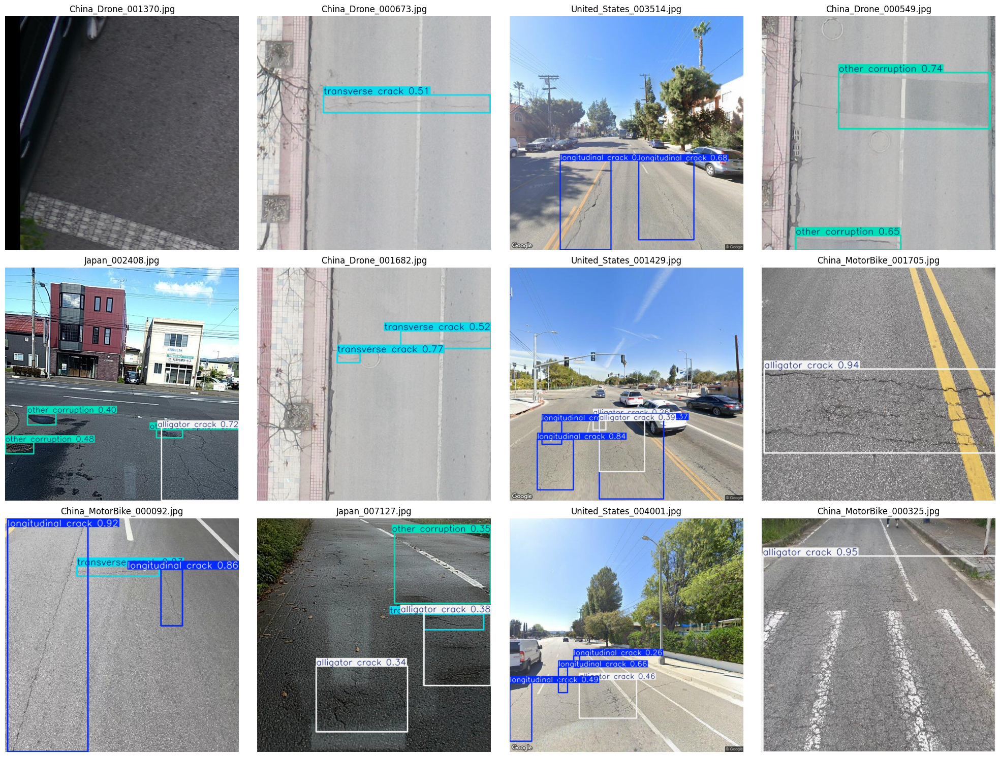

In [37]:
fig, axes = plt.subplots(
    3,
    4,
    figsize=(20, 15)
)

axes = axes.flatten()

for i, (image_path, result) in enumerate(
    zip(selected_images, results)
):

    annotated = result.plot()

    annotated = cv2.cvtColor(
        annotated,
        cv2.COLOR_BGR2RGB
    )

    axes[i].imshow(annotated)

    axes[i].set_title(
        image_path.name
    )

    axes[i].axis("off")

plt.tight_layout()
plt.show()

# Cell 15 — Severity weights

In [38]:
SEVERITY_WEIGHTS = {
    0: 1.0,   # longitudinal crack
    1: 1.0,   # transverse crack
    2: 1.5,   # alligator crack
    3: 0.75,  # other corruption
    4: 2.0    # pothole
}

CLASS_NAMES = {
    0: "Longitudinal Crack",
    1: "Transverse Crack",
    2: "Alligator Crack",
    3: "Other Corruption",
    4: "Pothole"
}

# Cell 16 — Severity + RHI function

In [39]:
def calculate_severity(result):

    image = result.orig_img

    height, width = image.shape[:2]

    image_area = height * width

    damage_score = 0.0
    damage_area = 0.0

    class_counts = {
        0: 0,
        1: 0,
        2: 0,
        3: 0,
        4: 0
    }

    detections = []

    if (
        result.boxes is None
        or len(result.boxes) == 0
    ):

        return {
            "damage_count": 0,
            "damage_area_percent": 0.0,
            "severity_score": 0.0,
            "severity_level": "Good",
            "rhi": 100.0,
            "class_counts": class_counts,
            "detections": detections
        }

    boxes = (
        result.boxes.xyxy
        .cpu()
        .numpy()
    )

    confidences = (
        result.boxes.conf
        .cpu()
        .numpy()
    )

    classes = (
        result.boxes.cls
        .cpu()
        .numpy()
        .astype(int)
    )

    for box, confidence, class_id in zip(
        boxes,
        confidences,
        classes
    ):

        x1, y1, x2, y2 = box

        box_width = max(
            0,
            x2 - x1
        )

        box_height = max(
            0,
            y2 - y1
        )

        box_area = (
            box_width *
            box_height
        )

        area_ratio = (
            box_area /
            image_area
        )

        class_counts[class_id] += 1

        weight = SEVERITY_WEIGHTS.get(
            class_id,
            1.0
        )

        confidence = float(
            confidence
        )

        # Area contribution
        area_factor = min(
            area_ratio * 20.0,
            1.0
        )

        # Individual damage contribution
        individual_score = (
            weight
            * confidence
            * (0.5 + area_factor)
        )

        damage_score += (
            individual_score
        )

        damage_area += area_ratio

        detections.append({
            "class_id": class_id,
            "class": CLASS_NAMES.get(
                class_id,
                f"Class {class_id}"
            ),
            "confidence": confidence,
            "bbox_area_percent":
                area_ratio * 100,
            "damage_score":
                individual_score
        })

    damage_area_percent = min(
        damage_area * 100,
        100
    )

    # Convert to 0-100 severity scale
    severity_score = min(
        damage_score * 15,
        100
    )

    # Road Health Index
    rhi = max(
        0,
        100 - severity_score
    )

    if severity_score < 20:
        severity_level = "Good"

    elif severity_score < 40:
        severity_level = "Fair"

    elif severity_score < 60:
        severity_level = "Poor"

    elif severity_score < 80:
        severity_level = "Very Poor"

    else:
        severity_level = "Critical"

    return {
        "damage_count": len(detections),
        "damage_area_percent":
            round(
                damage_area_percent,
                2
            ),
        "severity_score":
            round(
                severity_score,
                2
            ),
        "severity_level":
            severity_level,
        "rhi":
            round(
                rhi,
                2
            ),
        "class_counts":
            class_counts,
        "detections":
            detections
    }

# Cell 17 — Calculate severity for your images

In [40]:
analysis = []

for image_path, result in zip(
    selected_images,
    results
):

    severity = calculate_severity(
        result
    )

    counts = severity[
        "class_counts"
    ]

    analysis.append({

        "image":
            image_path.name,

        "longitudinal_crack":
            counts[0],

        "transverse_crack":
            counts[1],

        "alligator_crack":
            counts[2],

        "other_corruption":
            counts[3],

        "pothole":
            counts[4],

        "damage_count":
            severity[
                "damage_count"
            ],

        "damage_area_percent":
            severity[
                "damage_area_percent"
            ],

        "severity_score":
            severity[
                "severity_score"
            ],

        "severity_level":
            severity[
                "severity_level"
            ],

        "road_health_index":
            severity["rhi"]
    })

df = pd.DataFrame(
    analysis
)

df

,image,longitudinal_crack,transverse_crack,alligator_crack,other_corruption,pothole,damage_count,damage_area_percent,severity_score,severity_level,road_health_index
0,China_Drone_001370.jpg,0,0,0,0,0,0,0.000000,0.000000,Good,100.000000
1,China_Drone_000673.jpg,0,1,0,0,0,1,5.410000,11.550000,Good,88.450000
2,United_States_003514.jpg,2,0,0,0,0,2,16.250000,28.570000,Fair,71.430000
3,China_Drone_000549.jpg,0,0,0,2,0,2,18.250000,20.270000,Fair,79.730003
4,Japan_002408.jpg,0,0,1,3,0,4,11.940000,34.939999,Fair,65.059998
5,China_Drone_001682.jpg,0,2,0,0,0,2,3.360000,15.200000,Good,84.800003
6,United_States_001429.jpg,3,0,2,0,0,5,18.110001,41.250000,Poor,58.750000
7,China_MotorBike_001705.jpg,0,0,1,0,0,1,35.480000,31.830000,Fair,68.170000
8,China_MotorBike_000092.jpg,2,1,0,0,0,3,38.139999,42.840000,Poor,57.160000
9,Japan_007127.jpg,0,1,2,1,0,4,34.070000,33.389999,Fair,66.610001


# Cell 18 — Annotated images with severity and RHI

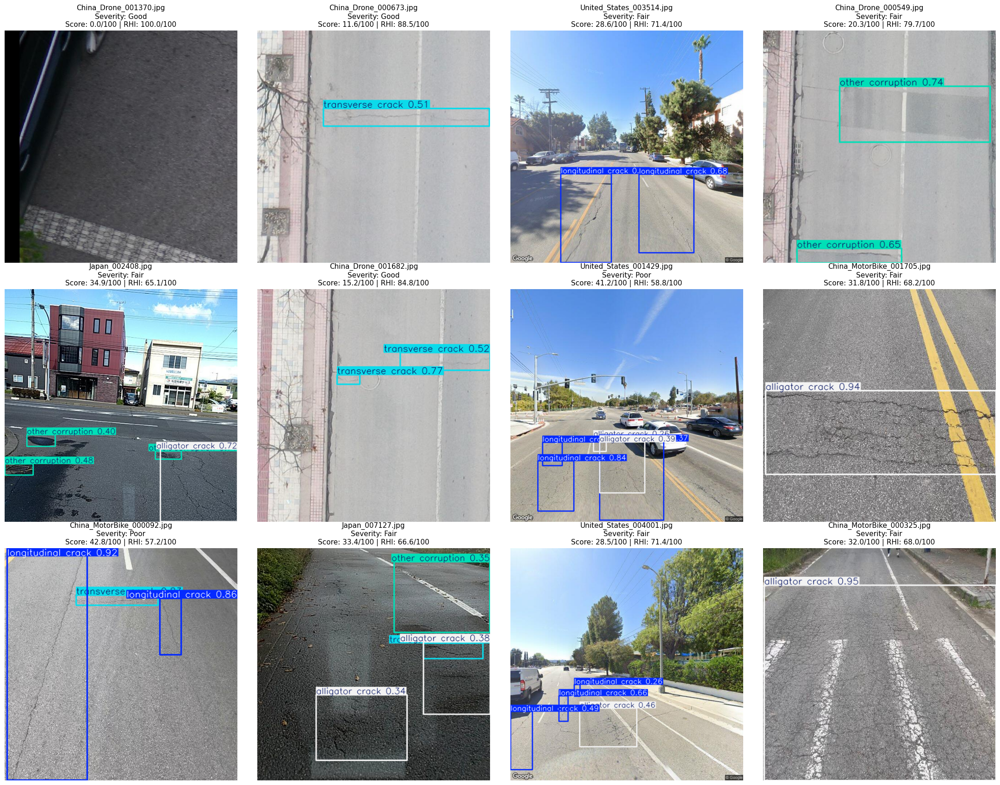

In [41]:
fig, axes = plt.subplots(
    3,
    4,
    figsize=(22, 17)
)

axes = axes.flatten()

for i, (
    image_path,
    result
) in enumerate(
    zip(
        selected_images,
        results
    )
):

    severity = calculate_severity(
        result
    )

    annotated = result.plot()

    annotated = cv2.cvtColor(
        annotated,
        cv2.COLOR_BGR2RGB
    )

    axes[i].imshow(
        annotated
    )

    axes[i].set_title(
        f"{image_path.name}\n"
        f"Severity: "
        f"{severity['severity_level']}\n"
        f"Score: "
        f"{severity['severity_score']:.1f}/100 | "
        f"RHI: "
        f"{severity['rhi']:.1f}/100",
        fontsize=11
    )

    axes[i].axis("off")

for i in range(
    len(selected_images),
    len(axes)
):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# Cell 19 — RHI graph

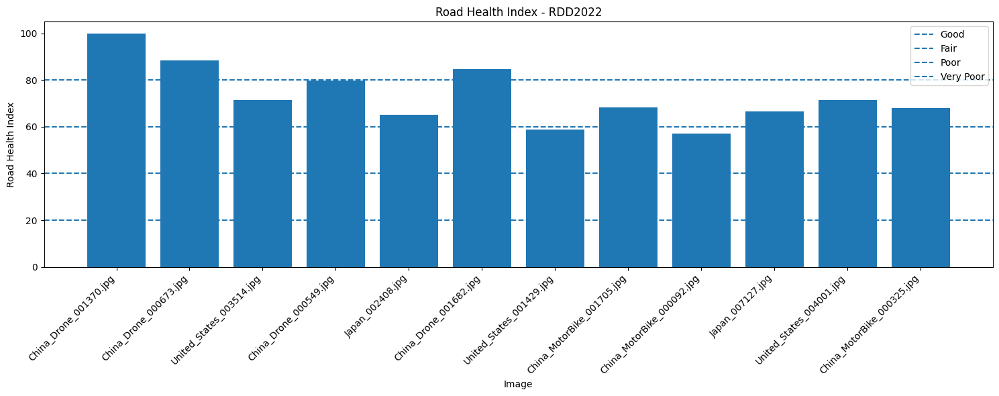

In [42]:
plt.figure(figsize=(15, 6))

plt.bar(
    range(len(df)),
    df["road_health_index"]
)

plt.axhline(
    80,
    linestyle="--",
    label="Good"
)

plt.axhline(
    60,
    linestyle="--",
    label="Fair"
)

plt.axhline(
    40,
    linestyle="--",
    label="Poor"
)

plt.axhline(
    20,
    linestyle="--",
    label="Very Poor"
)

plt.xticks(
    range(len(df)),
    df["image"],
    rotation=45,
    ha="right"
)

plt.ylabel(
    "Road Health Index"
)

plt.xlabel(
    "Image"
)

plt.title(
    "Road Health Index - RDD2022"
)

plt.legend()

plt.tight_layout()

plt.show()

# Cell 20 — Overall RHI

In [43]:
overall_rhi = df[
    "road_health_index"
].mean()

overall_severity = df[
    "severity_score"
].mean()

total_damages = df[
    "damage_count"
].sum()

average_damage_area = df[
    "damage_area_percent"
].mean()

if overall_rhi >= 80:
    overall_condition = "Good"

elif overall_rhi >= 60:
    overall_condition = "Fair"

elif overall_rhi >= 40:
    overall_condition = "Poor"

elif overall_rhi >= 20:
    overall_condition = "Very Poor"

else:
    overall_condition = "Critical"


print("=" * 60)
print("ROAD HEALTH ANALYSIS")
print("=" * 60)

print(
    f"Images analyzed       : "
    f"{len(df)}"
)

print(
    f"Total damages         : "
    f"{total_damages}"
)

print(
    f"Average damage area   : "
    f"{average_damage_area:.2f}%"
)

print(
    f"Average severity      : "
    f"{overall_severity:.2f}/100"
)

print(
    f"Road Health Index     : "
    f"{overall_rhi:.2f}/100"
)

print(
    f"Road condition        : "
    f"{overall_condition}"
)

print("=" * 60)

ROAD HEALTH ANALYSIS
Images analyzed       : 12
Total damages         : 29
Average damage area   : 22.61%
Average severity      : 26.70/100
Road Health Index     : 73.30/100
Road condition        : Fair


# Cell 21 — Save results

In [44]:
OUTPUT_DIR = Path(
    "/kaggle/working/rdd_severity_results"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CSV_FILE = (
    OUTPUT_DIR /
    "road_health_results.csv"
)

df.to_csv(
    CSV_FILE,
    index=False
)

print(
    "Results saved to:"
)

print(CSV_FILE)

Results saved to:
/kaggle/working/rdd_severity_results/road_health_results.csv
